# **Nombre: Ana Paula Martínez Rico**

## Práctica 4: TCOR

In [1]:
#funcion para leer archivos

def get_texts_from_file(path_corpus, path_truth):

    tr_txt = []
    tr_y = []

    with open(path_corpus, "r", encoding="utf-8") as f_corpus, open(path_truth, "r", encoding="utf-8") as f_truth:
    
        for twitt in f_corpus:
            tr_txt += [twitt]

        for label in f_truth:
            tr_y += [label]


    return tr_txt, tr_y

In [2]:
tr_txt, tr_y = get_texts_from_file("./mex20_train.txt", "./mex20_train_labels.txt")

## Ver los datos

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

Counter({'0\n': 3759, '1\n': 1519})


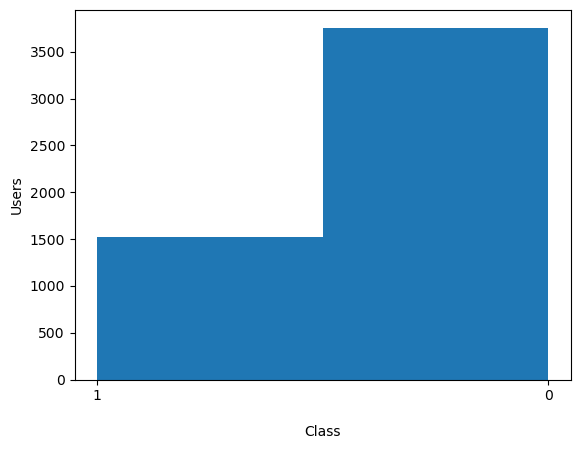

In [4]:
from collections import Counter

print(Counter(tr_y))

plt.hist(tr_y, bins=len(set(tr_y)))

plt.ylabel("Users")
plt.xlabel("Class")
plt.show()

In [5]:
from nltk.tokenize import TweetTokenizer
tokenizer= TweetTokenizer()

## Tokenizar todo el corpus

In [6]:
import nltk

corpus_palabras = []

for doc in tr_txt:
    corpus_palabras += tokenizer.tokenize(doc.lower())

In [7]:
fdist = nltk.FreqDist(corpus_palabras)

In [8]:
def sortFreqDist(freqdict): 
    aux = [(freqdict[key], key)for key in freqdict]
    aux.sort()
    aux.reverse()
    return aux # se convierte en el diccionario

In [9]:
V = sortFreqDist(fdist)

In [10]:
V = V[:1000]

## Diccionario de Índices

In [11]:
# Diccionario de Índices - Construir diccionario de Palabra/DimensionBow

dict_indices = dict() # dict_indices{PALABRA} = ÍNDICE
cont = 0
for weight, word in V:
    dict_indices[word] = cont
    cont += 1

In [12]:
import numpy as np

def build_bow_tr(tr_txt, V, dict_indices):

    BOW = np.zeros((len(tr_txt), len(V)), dtype=int)

    cont_doc = 0

    for tr in tr_txt: # recorrer cada tuit
        fdist_doc = nltk.FreqDist(tokenizer.tokenize(tr.lower())) # Tuit Tokenizado

        for word in fdist_doc: # para cada palabra en el tuit 
            if word in dict_indices: # para garantizar que solo veo palabras de mi vocabulario
                BOW[cont_doc, dict_indices[word]] = fdist_doc[word]

        cont_doc += 1
        


    return BOW

In [13]:
BOW_tr = build_bow_tr(tr_txt, V, dict_indices)

## Nueva Matriz

In [14]:
def compute_tcor(BOW):

    DTR = np.zeros((BOW.shape[1], BOW.shape[1]), dtype=np.float64)

    for doc, i in zip(BOW, range(len(BOW))):
        nonzero_position = np.nonzero(doc)[0]
        for t1 in nonzero_position:
            for t2 in nonzero_position:
                DTR[t1, t2] += 1.0


    return DTR
        

In [15]:
from sklearn import preprocessing
TCOR_base = compute_tcor(BOW_tr) 
TCOR_base = preprocessing.normalize(TCOR_base, norm='l2')

In [16]:
TCOR_base

array([[6.03137628e-01, 2.73582809e-01, 2.46119908e-01, ...,
        1.56930866e-03, 7.84654329e-04, 1.30775722e-03],
       [2.73098811e-01, 6.14602870e-01, 2.57694576e-01, ...,
        7.83266190e-04, 7.83266190e-04, 1.04435492e-03],
       [2.66691989e-01, 2.79729005e-01, 5.93467615e-01, ...,
        8.50240136e-04, 8.50240136e-04, 2.83413379e-04],
       ...,
       [3.04603850e-01, 1.52301925e-01, 1.52301925e-01, ...,
        4.06138466e-01, 0.00000000e+00, 0.00000000e+00],
       [1.87867287e-01, 1.87867287e-01, 1.87867287e-01, ...,
        0.00000000e+00, 5.00979433e-01, 0.00000000e+00],
       [3.03728370e-01, 2.42982696e-01, 6.07456739e-02, ...,
        0.00000000e+00, 0.00000000e+00, 4.85965391e-01]],
      shape=(1000, 1000))

In [17]:
from sklearn.feature_selection import SelectKBest, chi2

In [18]:
feats = SelectKBest(chi2, k=1000)
feats.fit(BOW_tr, tr_y)

,score_func,<function chi...001C0F6A21B20>
,k,1000


In [19]:
best = feats.get_support(indices=True)

In [20]:
# Mostrar las palabras que se seleccionaron
dict_indice_invertido = {}
for w in dict_indices:
    dict_indice_invertido[dict_indices[w]] = w

In [21]:
dict_indice_invertido

{0: 'que',
 1: 'de',
 2: ',',
 3: '.',
 4: 'la',
 5: 'a',
 6: 'y',
 7: 'no',
 8: 'me',
 9: '!',
 10: '@usuario',
 11: 'el',
 12: 'en',
 13: 'se',
 14: 'es',
 15: 'verga',
 16: 'madre',
 17: 'los',
 18: 'con',
 19: 'por',
 20: '?',
 21: 'las',
 22: 'mi',
 23: 'un',
 24: 'te',
 25: 'ya',
 26: 'si',
 27: 'putos',
 28: 'lo',
 29: '"',
 30: 'putas',
 31: 'una',
 32: 'para',
 33: 'como',
 34: '...',
 35: 'pero',
 36: 'su',
 37: '😂',
 38: 'tu',
 39: 'loca',
 40: 'le',
 41: 'más',
 42: 'gorda',
 43: 'yo',
 44: 'del',
 45: 'al',
 46: 'cuando',
 47: 'o',
 48: 'bien',
 49: 'son',
 50: 'estoy',
 51: '¿',
 52: 'qué',
 53: 'porque',
 54: 'feas',
 55: 'ni',
 56: 'está',
 57: 'les',
 58: 'pinche',
 59: 'esta',
 60: 'puta',
 61: 'todos',
 62: ':',
 63: 'ser',
 64: 'puto',
 65: 'sus',
 66: 'todo',
 67: 'soy',
 68: 'eso',
 69: 'tan',
 70: 'hdp',
 71: 'así',
 72: 'hasta',
 73: 'muy',
 74: 'hay',
 75: '…',
 76: 'mis',
 77: 'este',
 78: 'mamar',
 79: 'quiero',
 80: 'q',
 81: 'nos',
 82: 'solo',
 83: '¡',
 8

In [22]:
target_words = [dict_indice_invertido[index] for index in best]

In [23]:
target_matrix = np.array([TCOR_base[dict_indices[word]] for word in target_words])

In [24]:
from tsne import tsne

In [25]:
reduced_matrix = tsne(target_matrix, 2)

Preprocessing the data using PCA...
Computing pairwise distances...
Computing P-values for point 0 of 1000...
Computing P-values for point 500 of 1000...
Mean value of sigma: 0.130997
Iteration 10: error is 18.139181
Iteration 20: error is 18.071524
Iteration 30: error is 18.051684
Iteration 40: error is 18.007310
Iteration 50: error is 18.081312
Iteration 60: error is 18.104258
Iteration 70: error is 18.323566
Iteration 80: error is 18.282985
Iteration 90: error is 18.353612
Iteration 100: error is 18.303431
Iteration 110: error is 2.617634
Iteration 120: error is 2.218800
Iteration 130: error is 2.082887
Iteration 140: error is 2.014945
Iteration 150: error is 1.978853
Iteration 160: error is 1.951658
Iteration 170: error is 1.930151
Iteration 180: error is 1.913043
Iteration 190: error is 1.899151
Iteration 200: error is 1.887917
Iteration 210: error is 1.878945
Iteration 220: error is 1.871486
Iteration 230: error is 1.865043
Iteration 240: error is 1.859650
Iteration 250: error is

In [26]:
max_x = np.max(reduced_matrix, axis=0)[0]
max_y = np.max(reduced_matrix, axis=1)[1]

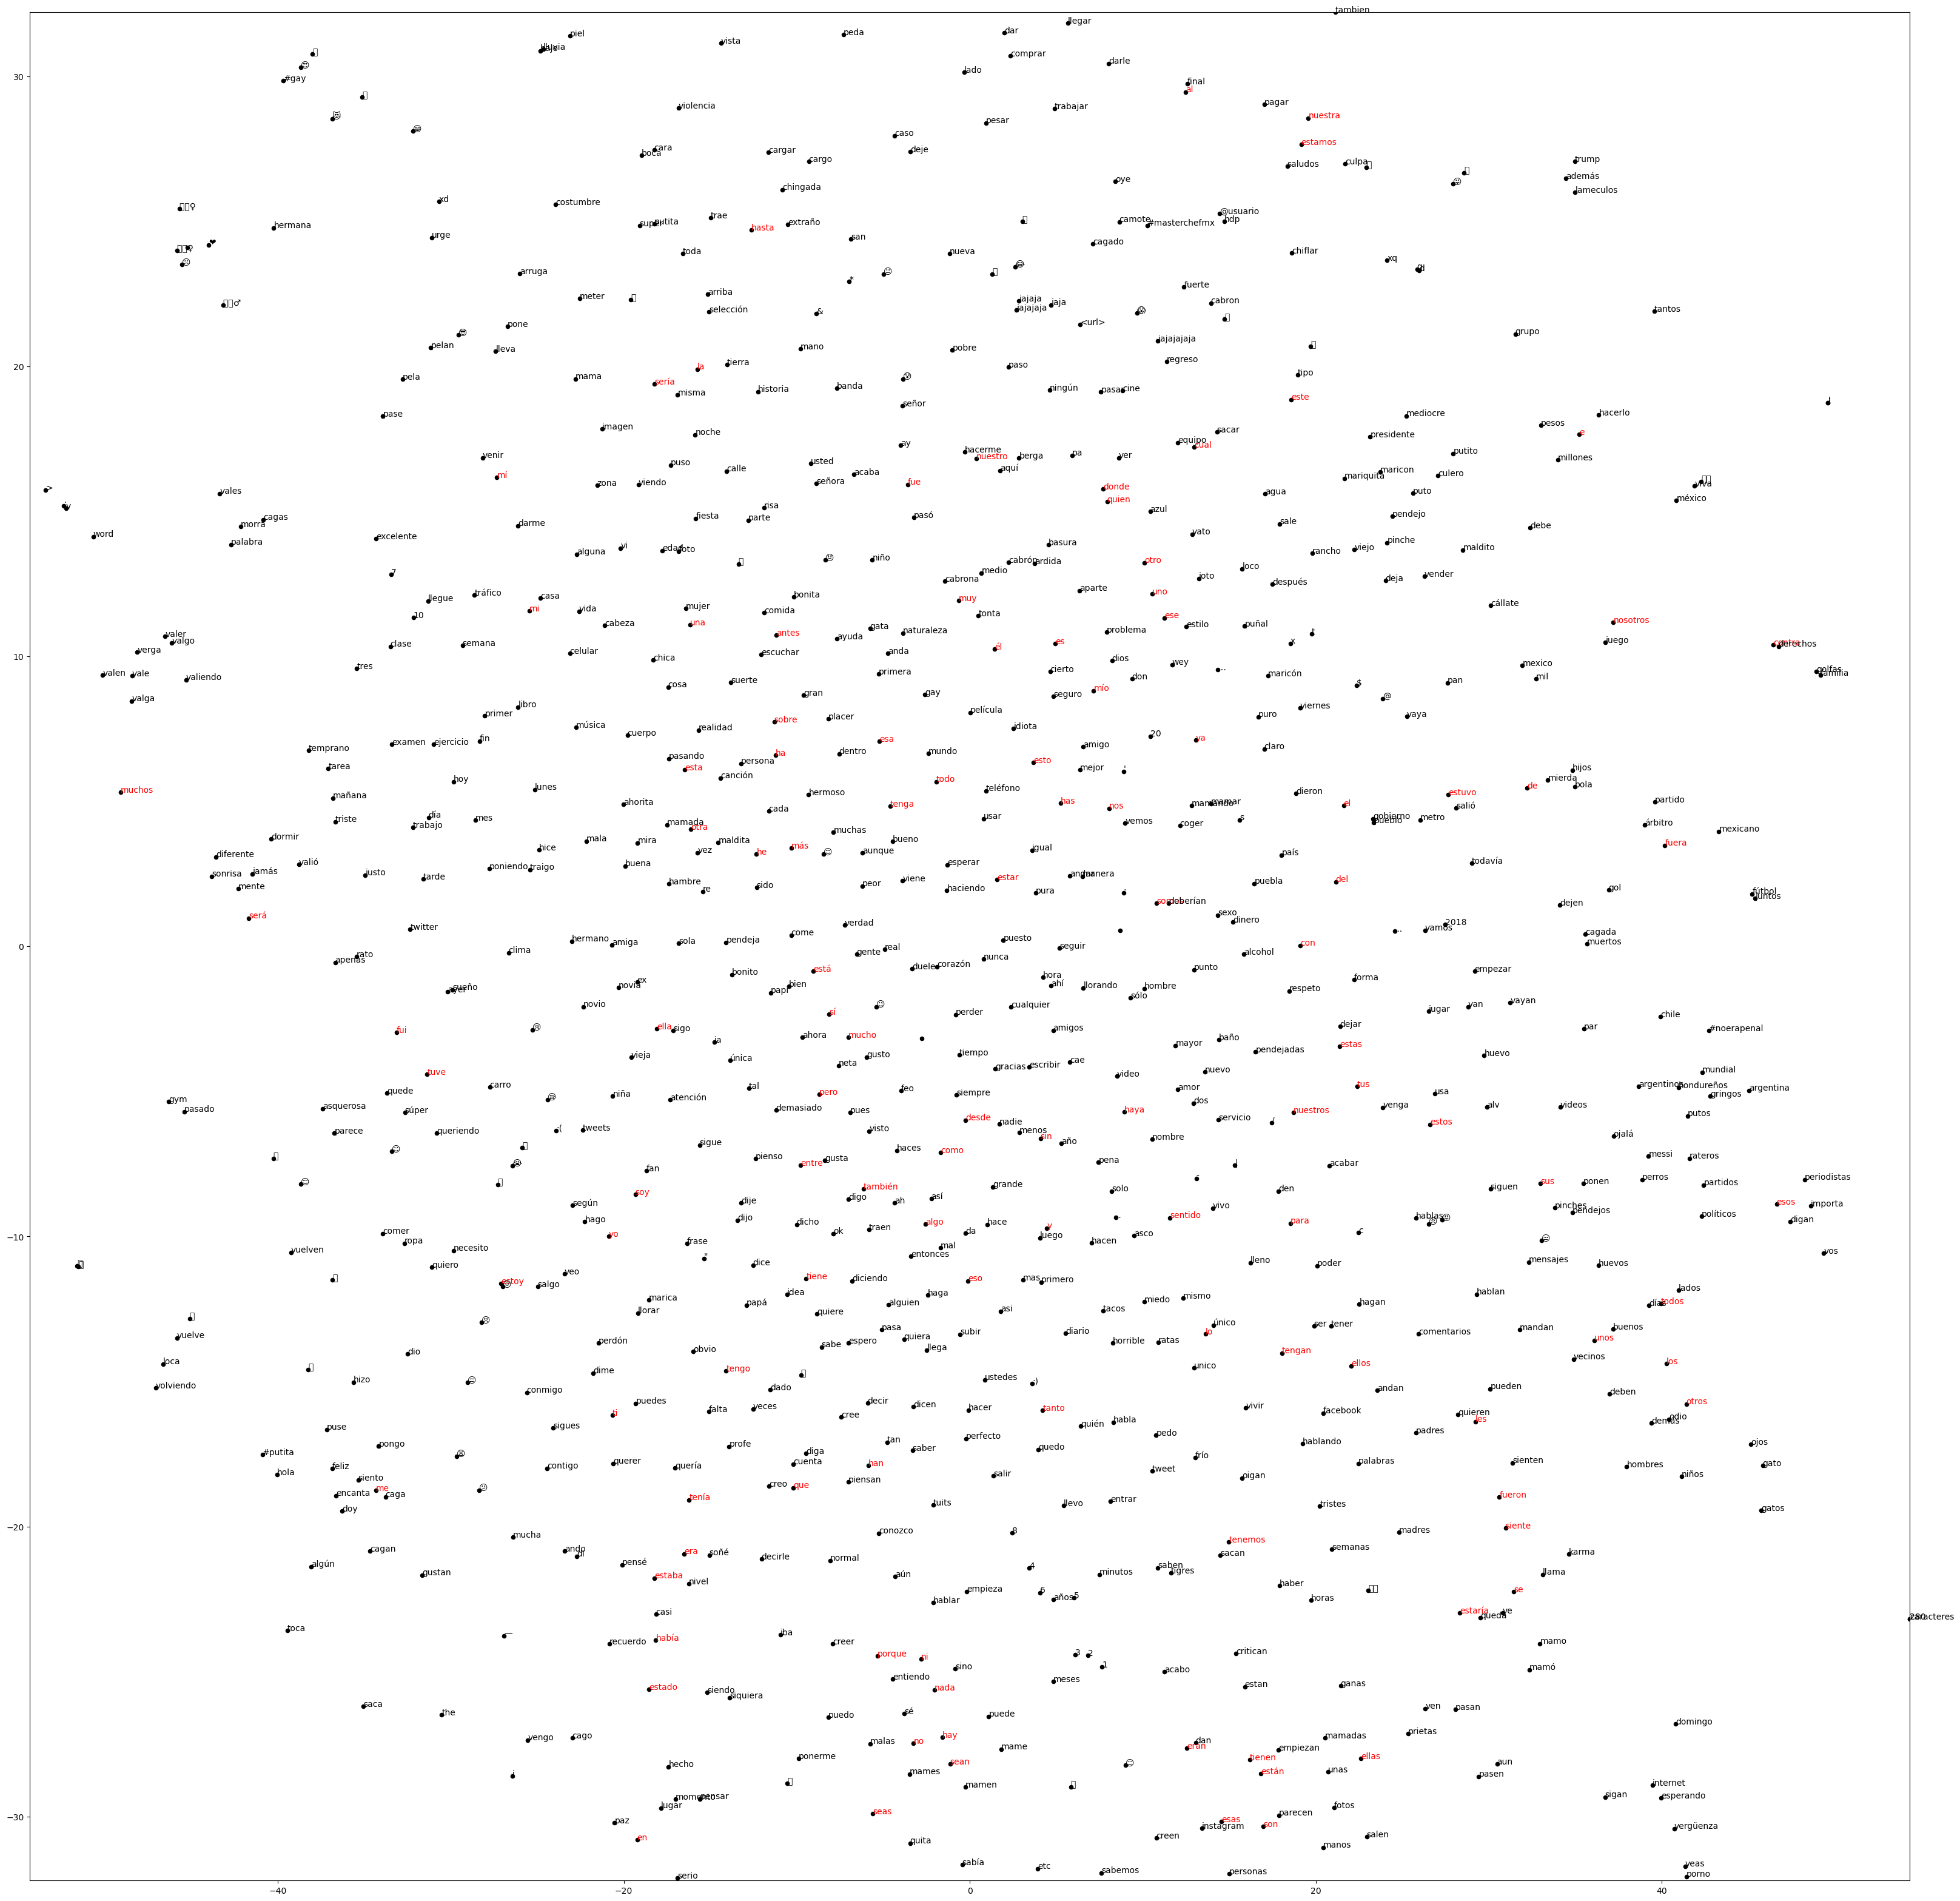

In [28]:
plt.figure(figsize=(40,40), dpi=100)

plt.xlim((-max_x, max_x))
plt.ylim((-max_y, max_y))

plt.scatter(reduced_matrix[:,0], reduced_matrix[:,1], 20, color="black")

# escribe la palabra

from nltk.corpus import stopwords
sw = stopwords.words("spanish")

for idx, word in enumerate(target_words):
    x = reduced_matrix[idx,0]
    y = reduced_matrix[idx,1]
    if word in sw:
        plt.annotate(word, (x,y), color="red")
    else:
        plt.annotate(word, (x,y), color="black")